## Primero ingresa tu código uniandes

In [1]:
codigo_estudiante = 202423300 #Completa con tu código uniandes

# Transformers Visuales (ViT)

Los Transformers Visuales (ViT) son una adaptación del modelo Transformer, originalmente desarrollado para tareas de procesamiento de lenguaje natural (NLP), para aplicarse en el dominio de la visión por computadora. Los Transformers se introdujeron en el artículo "Attention is All You Need" por Vaswani et al. en 2017, y han revolucionado muchas áreas del aprendizaje automático debido a su capacidad para capturar relaciones complejas en los datos a través del mecanismo de autoatención.

En este tutorial, construiremos un Transformer Visual (ViT) desde cero y lo entrenaremos para clasificar imágenes en el conjunto de datos MNIST. El proceso incluirá la carga y preprocesamiento de datos, la implementación de la arquitectura ViT, el entrenamiento del modelo y la evaluación de su rendimiento. Luego, tendrán la oportunidad de aplicar lo aprendido en una sección práctica, donde entrenarán un modelo preentrenado utilizando el conjunto de datos CIFAR-100 y explorarán cómo modificar y personalizar un ViT partiendo nuevamente de pesos preentrenados.

Comenzemos preparando el *enviroment* e importando las librerías necesarias. Recuerda que despues de instalar las librería debes reiniciar el Jupyter Kernel para utilizar los paquetes actualizados.

In [2]:
import numpy as np
import lm
from tqdm import tqdm, trange
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.nn import CrossEntropyLoss
from torch.utils.data import DataLoader
import torchvision
from torchvision.transforms import ToTensor, Compose
import matplotlib.pyplot as plt
import math
import gzip
import torch.optim as optim
from torchvision.datasets.mnist import MNIST
from sklearn.metrics import classification_report
from datasets import load_dataset
from torchvision import transforms
from transformers import ViTForImageClassification, ViTConfig
from transformers import ViTImageProcessor
from transformers import ViTModel
from torchvision import transforms
from PIL import Image
import random
from torchvision.datasets.mnist import MNIST
from sklearn.metrics import classification_report
from datasets import load_dataset
from torchvision import transforms
from transformers import ViTForImageClassification, ViTConfig
from transformers import ViTImageProcessor
from transformers import ViTModel
import zipfile
import os


# Asegura que los resultados sean replicables
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Fijar la semilla
set_seed(42)

## Contruyendo un Modelo ViT

 Ahora que hemos instalado e importado las librerías necesarias es hora de poner manos a la obra y construir nuestro propio modelo ViT. Vamos a empezar definiendo una clase vacía que herede de nn.Module. Luego, llenaremos esta clase paso a paso con los componentes necesarios para construir un ViT.

In [3]:
class MyViT(nn.Module):
  def __init__(self):
    # Super constructor
    super(MyViT, self).__init__()

  def forward(self, images):
    pass

Con esta estructura básica, estamos listos para añadir los componentes específicos del ViT uno por uno. A continuación, comenzaremos con la implementación de los embeddings de parches.

### El paso Forward

Ahora que hemos definido la estructura básica de nuestro modelo ViT, vamos a centrarnos en el **forward pass**, que es la parte donde el modelo toma una entrada (una imagen) y produce una salida (una predicción de clase). El forward pass es el componente clave que define cómo se procesan los datos a través de las diferentes capas del modelo. El backward pass, que maneja la retropropagación de errores y la actualización de los pesos, es manejado automáticamente por PyTorch durante el entrenamiento, por lo que no necesitamos implementarlo manualmente.

Tomemos la imagen de la arquitectura propuesta por Bazi et. al (2021) para guiar el proceso.

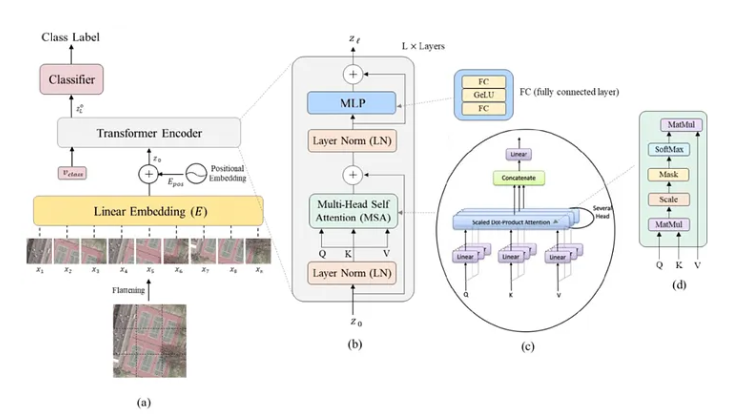

#### 1. Dividir la imagen y proyectarla a un espacio de mayor dimension

El primer paso en la construcción de un ViT es dividir la imagen de entrada en pequeños parches y proyectar cada parche en un espacio de mayor dimensión. Este proceso nos permite transformar la imagen en una secuencia de vectores, similar a cómo se tratan las palabras en una oración. Vamos a definir una clase `patchify` que se encargará de dividir la imagen en parches. Luego integramos esto a nuestro modelo, donde realizamos la operación de proyectar los parches a un espacio de mayor dimensionalidad.

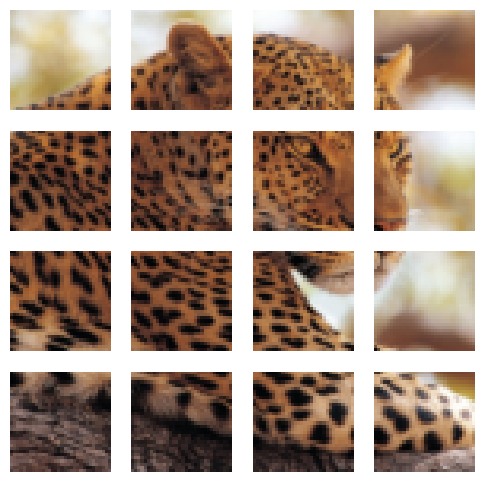

In [4]:
# Dividir la imagen en parches
def patchify(images, n_patches):
    n, c, h, w = images.shape

    assert h == w, "Patchify solo está implementado para imágenes cuadradas"

    patches = torch.zeros(n, n_patches**2, h * w * c // n_patches**2)
    patch_size = h // n_patches

    for idx, image in enumerate(images):
        for i in range(n_patches):
            for j in range(n_patches):
                patch = image[
                    :,
                    i * patch_size : (i + 1) * patch_size,
                    j * patch_size : (j + 1) * patch_size,
                ]
                patches[idx, i * n_patches + j] = patch.flatten()
    return patches

# Visualizar la división por medio de un ejemplo
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

image_path = "./archivos_ViT/leopardo.jpg"
image = Image.open(image_path).convert('RGB')
image_tensor = transform(image).unsqueeze(0)
n_patches = 4
patches = patchify(image_tensor, n_patches)
fig, axs = plt.subplots(n_patches, n_patches, figsize=(6, 6))
patch_size = 128 // n_patches

for i in range(n_patches):
    for j in range(n_patches):
        patch = patches[0, i * n_patches + j].view(3, patch_size, patch_size).permute(1, 2, 0).numpy()
        axs[i, j].imshow(patch)
        axs[i, j].axis('off')

plt.show()

Ahora que ya creamos nuestra función de `patchify`, es momento de integrarla a nuestro modelo. Para esto debemos inicializar la función con los parámetros necesarios y luego aplicar el embedding de parches a las imágenes de entrada.

La proyección de los parches a un espacio de alta dimensión, también conocida como "patch embedding", se realiza en la clase MyViT mediante la capa lineal (self.linear_mapper). Aquí es donde los vectores de los parches se proyectan al espacio de alta dimensión (espacio de hidden_d dimensiones).

In [5]:
class MyViT(nn.Module):
    def __init__(self, chw=(1, 28, 28), n_patches=7, hidden_d=8):
        # Super constructor
        super(MyViT, self).__init__()

        # Atributos
        self.chw = chw # (C, H, W)
        self.n_patches = n_patches
        self.hidden_d = hidden_d

        assert chw[1] % n_patches == 0, "La forma de entrada no es completamente divisible por el número de parches"
        assert chw[2] % n_patches == 0, "La forma de entrada no es completamente divisible por el número de parches"
        self.patch_size = (chw[1] / n_patches, chw[2] / n_patches)

        # 1) Mapeador lineal
        self.input_d = int(chw[0] * self.patch_size[0] * self.patch_size[1])
        self.linear_mapper = nn.Linear(self.input_d, self.hidden_d)

    def forward(self, images):
        # Dividir las imágenes en parches
        patches = patchify(images, self.n_patches)
        # Ejecutar la tokenización de la capa lineal
        tokens = self.linear_mapper(patches)
        return tokens

#### 2. Token de clasificación

En el diagrama de la arquitectura, podemos observar que también se pasa un token especial, denominado v_class, al Transformer Encoder. Este token tiene la función de capturar información sobre todos los demás tokens a través del bloque de Autoatención Multi-Cabeza (MHSA). El token de clasificación se inicializa como un vector aprendible y se concatena con los embeddings de los parches. Al final del proceso, el token de clasificación contendrá una representación agregada de toda la imagen, permitiendo clasificarla utilizando únicamente este token especial.

Implementemos esta parte en nuestra clase MyViT. Añadiremos el token de clasificación como un parámetro aprendible y lo concatenaremos con los embeddings de los parches.

In [6]:
class MyViT(nn.Module):
    def __init__(self, chw=(1, 28, 28), n_patches=7, hidden_d=8):
        # Super constructor
        super(MyViT, self).__init__()

        # Atributos
        self.chw = chw # (C, H, W)
        self.n_patches = n_patches
        self.hidden_d = hidden_d

        assert chw[1] % n_patches == 0, "La forma de entrada no es completamente divisible por el número de parches"
        assert chw[2] % n_patches == 0, "La forma de entrada no es completamente divisible por el número de parches"
        self.patch_size = (chw[1] / n_patches, chw[2] / n_patches)

        # 1) Mapeador lineal
        self.input_d = int(chw[0] * self.patch_size[0] * self.patch_size[1])
        self.linear_mapper = nn.Linear(self.input_d, self.hidden_d)

        # 2) Token de clasificación aprendible
        self.class_token = nn.Parameter(torch.rand(1, self.hidden_d))

    def forward(self, images):
        # Dividir las imágenes en parches
        patches = patchify(images, self.n_patches)
        # Ejecutar la tokenización de la capa lineal
        tokens = self.linear_mapper(patches)

        # Añadir el token de clasificación a los tokens
        tokens = torch.stack([torch.vstack((self.class_token, tokens[i])) for i in range(len(tokens))])
        return tokens

#### 3. Codificaciones posicionales

Ahora que hemos añadido el token de clasificación a nuestro modelo ViT, es momento de incorporar las codificaciones posicionales. Las codificaciones posicionales son cruciales porque los Transformers no tienen una noción inherente de la posición de los tokens en la secuencia. Estas codificaciones añaden información sobre la posición de cada parche en la imagen, permitiendo al modelo capturar la estructura espacial de los datos.

Definamos una función `get_positional_embeddings` que se encargará de generar las codificaciones posicionales para que luego sean agregadas a los embeddings de los parches y el token de clasificación.

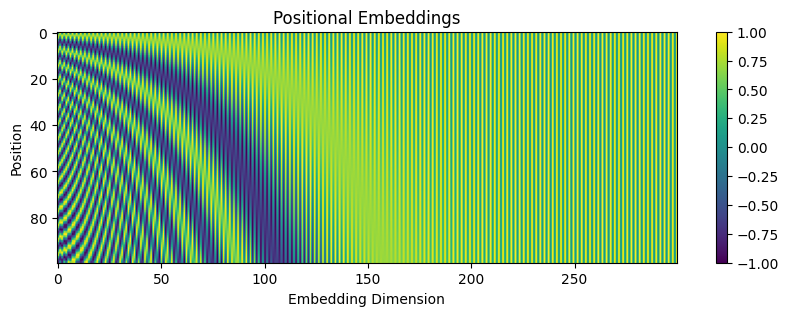

In [7]:
# Embedding posicionales
def get_positional_embeddings(sequence_length, d):
    result = torch.ones(sequence_length, d)
    for i in range(sequence_length):
        for j in range(d):
            result[i][j] = np.sin(i / (10000 ** (j / d))) if j % 2 == 0 else np.cos(i / (10000 ** ((j - 1) / d)))
    return result


# Visualizar enbeddings positionales
def visualize_positional_embeddings(sequence_length, d):
    embeddings = get_positional_embeddings(sequence_length, d)
    plt.figure(figsize=(10, 3))
    plt.imshow(embeddings.numpy(), aspect='auto', cmap='viridis')
    plt.colorbar()
    plt.title('Positional Embeddings')
    plt.xlabel('Embedding Dimension')
    plt.ylabel('Position')
    plt.show()

visualize_positional_embeddings(100, 300)

La imagen muestra una visualización de los embeddings posicionales. Estos embeddings son vectores añadidos a los parches aplanados para proporcionar información sobre su posición en la imagen. Los vectores se generan utilizando funciones seno y coseno, lo que garantiza que cada posición tenga un vector distinto y único. Esto significa que, incluso si dos parches tienen características similares, sus embeddings posicionales serán diferentes si están en distintas posiciones. Esto ayuda al Transformer a mantener la información sobre el orden y la ubicación de los parches.

A continuación, proporcionamos un código que divide una imagen en parches, genera embeddings posicionales utilizando funciones seno y coseno, suma los embeddings posicionales a los vectores de parches, y finalmente visualiza los parches con los embeddings posicionales añadidos. Esta visualización muestra cómo se añade la información posicional a cada parche, permitiendo al modelo reconocer no solo las características de cada parche, sino también su posición relativa en la imagen.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

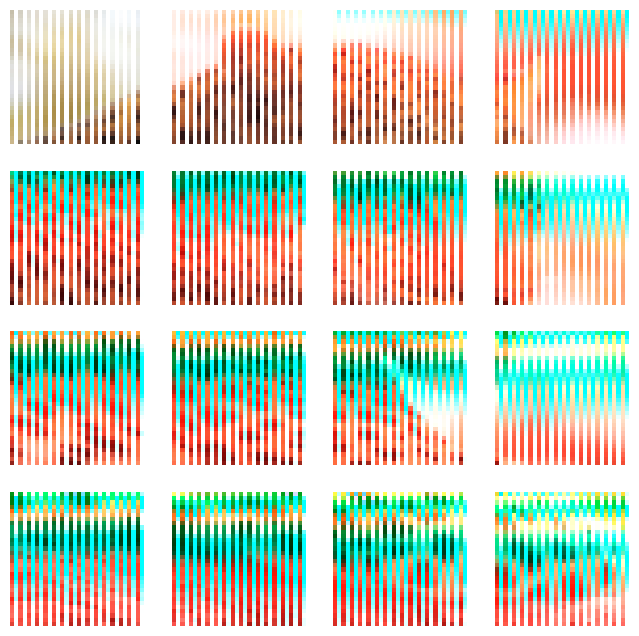

In [8]:
# Cargar una imagen de ejemplo y convertirla a tensor
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

image_path = "./archivos_ViT/leopardo.jpg"
image = Image.open(image_path).convert('RGB')
image_tensor = transform(image).unsqueeze(0)

# Dividir la imagen en parches
n_patches = 4
patches = patchify(image_tensor, n_patches)

# Generar embeddings posicionales
def generate_positional_encodings(n_patches, dim):
    position = torch.arange(0, n_patches**2).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, dim, 2) * -(np.log(10000.0) / dim))
    pos_encodings = torch.zeros(n_patches**2, dim)
    pos_encodings[:, 0::2] = torch.sin(position * div_term)
    pos_encodings[:, 1::2] = torch.cos(position * div_term)
    return pos_encodings

dim = patches.size(-1)
pos_encodings = generate_positional_encodings(n_patches, dim)

# Sumar embeddings posicionales a los parches
patches_with_pos = patches + pos_encodings

# Visualizar los parches
fig, axs = plt.subplots(n_patches, n_patches, figsize=(8, 8))
patch_size = 128 // n_patches

for i in range(n_patches):
    for j in range(n_patches):
        patch = patches_with_pos[0, i * n_patches + j].view(3, patch_size, patch_size).permute(1, 2, 0).numpy()
        axs[i, j].imshow(patch)
        axs[i, j].axis('off')

plt.show()

Ahora actualizemos nuestra clase MyViT para incluir las codificaciones posicionales.

In [10]:
class MyViT(nn.Module):
    def __init__(self, chw=(1, 28, 28), n_patches=7, hidden_d=8):
        # Super constructor
        super(MyViT, self).__init__()

        # Atributos
        self.chw = chw # (C, H, W)
        self.n_patches = n_patches
        self.hidden_d = hidden_d

        assert chw[1] % n_patches == 0, "La forma de entrada no es completamente divisible por el número de parches"
        assert chw[2] % n_patches == 0, "La forma de entrada no es completamente divisible por el número de parches"
        self.patch_size = (chw[1] / n_patches, chw[2] / n_patches)

        # 1) Mapeador lineal
        self.input_d = int(chw[0] * self.patch_size[0] * self.patch_size[1])
        self.linear_mapper = nn.Linear(self.input_d, self.hidden_d)

        # 2) Token de clasificación aprendible
        self.class_token = nn.Parameter(torch.rand(1, self.hidden_d))

        # 3) Embedding posicional
        self.pos_embed = nn.Parameter(torch.tensor(get_positional_embeddings(self.n_patches ** 2 + 1, self.hidden_d)))
        self.pos_embed.requires_grad = False

    def forward(self, images):
        # Dividir las imágenes en parches
        patches = patchify(images, self.n_patches)
        # Ejecutar la tokenización de la capa lineal
        tokens = self.linear_mapper(patches)

        # Añadir el token de clasificación a los tokens
        tokens = torch.stack([torch.vstack((self.class_token, tokens[i])) for i in range(len(tokens))])

        # Añadir el embedding posicional
        pos_embed = self.pos_embed.repeat(tokens.size(0), 1, 1)
        out = tokens + pos_embed
        return out

#### 4. Bloque del Transformer Encoder

El bloque del Transformer Encoder es una parte fundamental del modelo ViT, y está compuesto por varias capas. Como vemos en el diagrama de la arquitectura, este bloque se organiza de la siguiente manera:
1. **Capa de Normalización**
2. **Autoatención Multicabeza**
3. **Conexión Residual**
4. **Capa de Normalización**
5. **MLP**
6. **Conexión Residual Final**

Empezaremos creando una clase para la autoatención multi-cabeza (Multi-Head Self-Attention, MHSA). Este mecanismo permite que cada parche de una imagen se actualice en función de su similitud con otros parches. Esto se logra mediante el mapeo lineal de cada parche a tres vectores distintos: q (query), k (key) y v (value), y calculando la atención basada en estos vectores. A continuación, se detalla paso a paso cómo se implementa esta clase.

Primero debemos inicializar nuestra clase, la cual toma dos parámteros: d, que es la dimensión del vector de características de entrada, y n_heads, que es el número de cabezas de atención.

In [11]:
class MyMHSA(nn.Module):
    def __init__(self, d, n_heads=2):
        super(MyMHSA, self).__init__()
        self.d = d
        self.n_heads = n_heads

        assert d % n_heads == 0, f"No se puede dividir la dimensión {d} en {n_heads} cabezas"

Luego, inicializamos los mapeos lineales para los vectores q, k y v mediante nn.ModuleList. d_head representa la dimensión de cada sub-vector de cabeza, calculada como d // n_heads. Cada cabeza de atención tiene su propio conjunto de mapeos para q, k y v. Además, definimos self.softmax, que es una función de activación softmax utilizada para calcular las probabilidades de atención.

In [12]:
class MyMHSA(nn.Module):
    def __init__(self, d, n_heads=2):
        super(MyMHSA, self).__init__()
        self.d = d
        self.n_heads = n_heads

        assert d % n_heads == 0, f"No se puede dividir la dimensión {d} en {n_heads} cabezas"

        d_head = int(d / n_heads)
        self.q_mappings = nn.ModuleList([nn.Linear(d_head, d_head) for _ in range(self.n_heads)])
        self.k_mappings = nn.ModuleList([nn.Linear(d_head, d_head) for _ in range(self.n_heads)])
        self.v_mappings = nn.ModuleList([nn.Linear(d_head, d_head) for _ in range(self.n_heads)])
        self.d_head = d_head
        self.softmax = nn.Softmax(dim=-1)


Finalmente, definimos el método *forward* donde primero dividimos la secuencia de entrada en sub-vectores para cada cabeza. Luego, para cada cabeza, aplicamos los mapeos lineales para obtener los vectores q, k y v. Calculamos el producto punto entre q y k, lo dividimos por la raíz cuadrada de la dimensión de la cabeza (d_head ** 0.5), y aplicamos softmax para obtener los pesos de atención. Estos pesos de atención se multiplican por v para obtener las representaciones de salida para cada cabeza. Finalmente, concatenamos las representaciones de todas las cabezas a lo largo de la dimensión de características para formar la salida final de la capa de atención.

In [13]:
class MyMHSA(nn.Module):
    def __init__(self, d, n_heads=2):
        super(MyMHSA, self).__init__()
        self.d = d
        self.n_heads = n_heads

        assert d % n_heads == 0, f"No se puede dividir la dimensión {d} en {n_heads} cabezas"

        d_head = int(d / n_heads)
        self.q_mappings = nn.ModuleList([nn.Linear(d_head, d_head) for _ in range(self.n_heads)])
        self.k_mappings = nn.ModuleList([nn.Linear(d_head, d_head) for _ in range(self.n_heads)])
        self.v_mappings = nn.ModuleList([nn.Linear(d_head, d_head) for _ in range(self.n_heads)])
        self.d_head = d_head
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, sequences):
        result = []
        for sequence in sequences:
            seq_result = []
            for head in range(self.n_heads):
                q_mapping = self.q_mappings[head]
                k_mapping = self.k_mappings[head]
                v_mapping = self.v_mappings[head]

                seq = sequence[:, head * self.d_head: (head + 1) * self.d_head]
                q, k, v = q_mapping(seq), k_mapping(seq), v_mapping(seq)

                attention = self.softmax(q @ k.T / (self.d_head ** 0.5))
                seq_result.append(attention @ v)
            result.append(torch.hstack(seq_result))
        return torch.cat([torch.unsqueeze(r, dim=0) for r in result])

Ahora que ya tenemos nuestra clase de autoatención multi-cabeza, podemos pasar a definir la primera parte del bloque del encoder, la cual aplica una capa de normalización (Layer Normalization) a los tokens, seguida de la autoatención multi-cabeza (Multi-head Self Attention). Después, se añade una conexión residual (Residual Connection).

In [ ]:
class MyViTBlock(nn.Module):
    def __init__(self, hidden_d, n_heads, mlp_ratio=4):
        super(MyViTBlock, self).__init__()
        self.hidden_d = hidden_d
        self.n_heads = n_heads
        # Capa de normalización
        self.norm1 = nn.LayerNorm(hidden_d)
        # Autoatención multi-cabeza
        self.mhsa = MyMHSA(hidden_d, n_heads)

    def forward(self, x):
        # Conexión Residual
        out = x + self.mhsa(self.norm1(x))
        return out

La segunda parte del bloque aplica otra normalización de capa, seguida por una red MLP. La MLP amplía las dimensiones del embedding antes de reducirlo nuevamente a su dimensión original. Finalmente, se añade otra conexión residual después de pasar el tensor actual a través de estos componentes. Agregemos esto a nuestro bloque.

In [14]:
class MyViTBlock(nn.Module):
    def __init__(self, hidden_d, n_heads, mlp_ratio=4):
        super(MyViTBlock, self).__init__()
        self.hidden_d = hidden_d
        self.n_heads = n_heads
        # Capa de normalización
        self.norm1 = nn.LayerNorm(hidden_d)
        # Autoatención multi-cabeza
        self.mhsa = MyMHSA(hidden_d, n_heads)
        # Capa de normalización
        self.norm2 = nn.LayerNorm(hidden_d)
        # Capa MLP
        self.mlp = nn.Sequential(
            nn.Linear(hidden_d, mlp_ratio*hidden_d),
            nn.ReLU(),
            nn.Linear(mlp_ratio*hidden_d, hidden_d),
        )

    def forward(self, x):
        # Conexión residual
        out = x + self.mhsa(self.norm1(x))
        # Conexión residual
        out = out + self.mlp(self.norm2(out))
        return out

Listo, nuestra clase `TransformerEncoder` ya esta terminada. Ahora integremos este bloque en nuestro modelo.

In [15]:
class MyViT(nn.Module):
    def __init__(self, chw, n_patches=7, n_blocks=2, hidden_d=8, n_heads=2, out_d=10):
        # Super constructor
        super(MyViT, self).__init__()

        # Atributos
        self.chw = chw # (C, H, W)
        self.n_patches = n_patches
        self.n_blocks = n_blocks
        self.n_heads = n_heads
        self.hidden_d = hidden_d

        # Tamaños de entrada y parches
        assert chw[1] % n_patches == 0, "La forma de entrada no es completamente divisible por el número de parches"
        assert chw[2] % n_patches == 0, "La forma de entrada no es completamente divisible por el número de parches"
        self.patch_size = (chw[1] / n_patches, chw[2] / n_patches)

        # 1) Mapeador lineal
        self.input_d = int(chw[0] * self.patch_size[0] * self.patch_size[1])
        self.linear_mapper = nn.Linear(self.input_d, self.hidden_d)

        # 2) Token de clasificación aprendible
        self.class_token = nn.Parameter(torch.rand(1, self.hidden_d))

        # 3) Embedding posicional
        self.register_buffer('positional_embeddings', get_positional_embeddings(n_patches ** 2 + 1, hidden_d), persistent=False)

        # 4) Bloques del codificador Transformer
        self.blocks = nn.ModuleList([MyViTBlock(hidden_d, n_heads) for _ in range(n_blocks)])

    def forward(self, images):
        # Dividir las imágenes en parches
        n, c, h, w = images.shape
        patches = patchify(images, self.n_patches).to(self.positional_embeddings.device)

        # Ejecutar la tokenización de la capa lineal
        # Mapear el vector correspondiente a cada parche a la dimensión de tamaño oculto
        tokens = self.linear_mapper(patches)

        # Añadir el token de clasificación a los tokens
        tokens = torch.cat((self.class_token.expand(n, 1, -1), tokens), dim=1)

        # Añadir el embedding posicional
        out = tokens + self.positional_embeddings.repeat(n, 1, 1)

        # Bloques Transformer
        for block in self.blocks:
            out = block(out)

        return out

#### 5. Clasificación con MLP

La última parte de nuestro modelo ViT es la cabeza de clasificación, que utilizaremos para predecir la clase de la imagen. Esta capa de clasificación será una red MLP simple, que tomará la salida del token de clasificación y la transformará en una distribución de probabilidad sobre las posibles clases. Implementemos esto en nuestro modelo.

In [16]:
class MyViT(nn.Module):
    def __init__(self, chw, n_patches=7, n_blocks=2, hidden_d=8, n_heads=2, out_d=10):
        # Super constructor
        super(MyViT, self).__init__()

        # Atributos
        self.chw = chw # (C, H, W)
        self.n_patches = n_patches
        self.n_blocks = n_blocks
        self.n_heads = n_heads
        self.hidden_d = hidden_d

        # Tamaños de entrada y parches
        assert chw[1] % n_patches == 0, "La forma de entrada no es completamente divisible por el número de parches"
        assert chw[2] % n_patches == 0, "La forma de entrada no es completamente divisible por el número de parches"
        self.patch_size = (chw[1] / n_patches, chw[2] / n_patches)

        # 1) Mapeador lineal
        self.input_d = int(chw[0] * self.patch_size[0] * self.patch_size[1])
        self.linear_mapper = nn.Linear(self.input_d, self.hidden_d)

        # 2) Token de clasificación aprendible
        self.class_token = nn.Parameter(torch.rand(1, self.hidden_d))

        # 3) Embedding posicional
        self.register_buffer('positional_embeddings', get_positional_embeddings(n_patches ** 2 + 1, hidden_d), persistent=False)

        # 4) Bloques del codificador Transformer
        self.blocks = nn.ModuleList([MyViTBlock(hidden_d, n_heads) for _ in range(n_blocks)])

        # 5) MLP de clasificación
        self.mlp = nn.Linear(self.hidden_d, out_d)


    def forward(self, images):
        # Dividir las imágenes en parches
        n, c, h, w = images.shape
        patches = patchify(images, self.n_patches).to(self.positional_embeddings.device)

        # Ejecutar la tokenización de la capa lineal
        # Mapear el vector correspondiente a cada parche a la dimensión de tamaño oculto
        tokens = self.linear_mapper(patches)

        # Añadir el token de clasificación a los tokens
        tokens = torch.cat((self.class_token.expand(n, 1, -1), tokens), dim=1)

        # Añadir el embedding posicional
        out = tokens + self.positional_embeddings.repeat(n, 1, 1)

        # Bloques Transformer
        for block in self.blocks:
            out = block(out)

        # Obtener solo el token de clasificación
        out = out[:, 0]

        return self.mlp(out) # Mapear a la dimensión de salida, distribución de categorías de salida

In [17]:
# Verificar que el modelo funcione correctamente con entradas de tamaño correcto
model = MyViT(chw=(1, 28, 28), n_patches=7, n_blocks=2, hidden_d=8, n_heads=2, out_d=10)
images = torch.randn(8, 1, 28, 28)  # Lote de 8 imágenes de 28x28 con 1 canal
outputs = model(images)
print(outputs.shape)  # Debe ser [8, 10] para 8 imágenes y 10 clases

torch.Size([8, 10])


### Entrenamiendo del Modelo ViT

Con esta implementación, hemos completado el modelo ViT con una cabeza de clasificación final. Ahora el modelo está listo para ser entrenado y evaluado en el conjunto de datos MNIST.
Empezemos descargando las imagenes de la base de datos, luego las preprocesamos para que se adapten correctamente a nuestro modelo y finalmente dividimos las imagenes en conjuntos de entrenamiento y prueba.

In [18]:
# Definir la transformación que convierte las imagenes tensor
transform = Compose([
    ToTensor()
])

# Cargar imagenes
def load_mnist_images(file_path):
    with gzip.open(file_path, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16).reshape(-1, 28, 28, 1)
        return data

# cargar etiquetas
def load_mnist_labels(file_path):
    with gzip.open(file_path, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=8)
        return data

# Rutas a los archivos
train_images_path = './archivos_ViT/MNIST/train-images-idx3-ubyte.gz'
train_labels_path = './archivos_ViT/MNIST/train-labels-idx1-ubyte.gz'
test_images_path = './archivos_ViT/MNIST/t10k-images-idx3-ubyte.gz'
test_labels_path = './archivos_ViT/MNIST/t10k-labels-idx1-ubyte.gz'

# Llamar funciones para cargar datos
train_images = load_mnist_images(train_images_path)[:5000]
train_labels = load_mnist_labels(train_labels_path)[:5000]
test_images = load_mnist_images(test_images_path)[:1000]
test_labels = load_mnist_labels(test_labels_path)[:1000]

# Aplicar transformación a las imágenes
train_images = torch.stack([transform(image) for image in train_images])
test_images = torch.stack([transform(image) for image in test_images])

# Crear conjuntos de datos
train_set = torch.utils.data.TensorDataset(train_images, torch.tensor(train_labels, dtype=torch.long))
test_set = torch.utils.data.TensorDataset(test_images, torch.tensor(test_labels, dtype=torch.long))

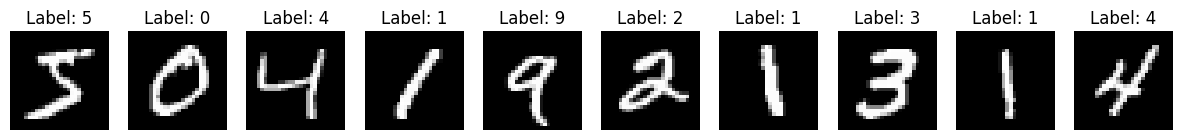

In [22]:
# Generar los dataloaders
set_seed(42)
train_loader = DataLoader(train_set, shuffle=True, batch_size=32)
test_loader = DataLoader(test_set, shuffle=False, batch_size=32)

# Función para visualización de imagenes
def show_images(dataset, num_images=10):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 15))
    for i in range(num_images):
        image, label = dataset[i]
        axes[i].imshow(image.squeeze(), cmap='gray')
        axes[i].set_title(f"Label: {label}")
        axes[i].axis('off')
    plt.show()

# Visualizar 10 imágenes del conjunto de entrenamiento
show_images(train_set, num_images=10)

Ahora configuremos los parámetros de entrenamiento como la tasa de aprendizaje y el número de épocas. Además definimos la función de pérdida y el optimizador.

In [23]:
# Definir el dispositivo
device = torch.device('cuda')
print(device)

#Inicializar el modelo
model = MyViT((1, 28, 28), n_patches=7, n_blocks=2, hidden_d=8, n_heads=2, out_d=10).to(device)

# Definir la función de pérdida y el optimizador
optimizer = optim.AdamW(model.parameters(), lr=5e-3)
criterion = nn.CrossEntropyLoss()

num_epochs = 10

cuda


Estamos listos para entrenar nuestro modelo ViT personalizado utilizando los **data loaders** que hemos creado. El proceso de entrenamiento implica pasar las imágenes de entrenamiento por lotes (batch) a través del modelo, calcular la pérdida utilizando la función de pérdida *CrossEntropyLoss*, y luego actualizar los pesos del modelo mediante retropropagación y el optimizador *AdamW*.

In [24]:
# Entrenar modelo
for epoch in range(num_epochs):
    train_loss = 0.0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1} in training", leave=False):
        x, y = batch
        x, y = x.to(device), y.to(device)
        pred = model(x)
        loss = criterion(pred, y)
        train_loss += loss.detach().cpu().item() / len(train_loader)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    print(f"Epoch {epoch + 1}/{num_epochs} loss: {train_loss:.2f}")

print('Finished Training')

# Guardar el modelo entrenado
torch.save(model.state_dict(), 'my_vit_model.pth')

Epoch 1/10 loss: 2.07


Epoch 2/10 loss: 1.74


Epoch 3/10 loss: 1.36


Epoch 4/10 loss: 1.21


Epoch 5/10 loss: 1.08


Epoch 6/10 loss: 0.91


Epoch 7/10 loss: 0.82


Epoch 8/10 loss: 0.73


Epoch 9/10 loss: 0.71


Epoch 10/10 loss: 0.61
Finished Training


Finalmente, evaluamos nuestro modelo en el conjunto de datos de prueba para verificar su capacidad de clasificación en datos no vistos anteriormente. Esto nos permitirá medir el rendimiento del modelo y asegurarnos de que generaliza bien más allá de los datos de entrenamiento.

In [25]:
# Evaluar el modelo
model.load_state_dict(torch.load('my_vit_model.pth'))
model.eval()

eval_loss = 0.0
correct = 0
total = 0
all_labels = []
all_predictions = []

# Datos para visualización
images_to_show = 10
images, labels, predictions = [], [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        # Defino las imágenes y las etiquetas con base a la organización del mi batch
        x, y = batch
        x, y = x.to(device), y.to(device)
        # Prediccion del modelo
        pred = model(x)
        # Cuenta el total y las predicciones correctas
        # Calcular la precisión y recolectar todas las etiquetas y predicciones
        _, predicted = torch.max(pred, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

        all_labels.extend(y.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

        # Recolectar imágenes para visualización
        if len(images) < images_to_show:
            for i in range(len(x)):
                if len(images) < images_to_show:
                    images.append(x[i].cpu())
                    labels.append(y[i].cpu().item())
                    predictions.append(predicted[i].cpu().item())
                if len(images) >= images_to_show:
                    break

accuracy = 100 * correct / total
print(f"Evaluation loss: {eval_loss:.2f}")
print(f"Accuracy: {accuracy:.2f}%")

# Generar el informe de clasificación
target_names = [str(i) for i in range(10)]  # Asumiendo 10 clases para MNIST
report = classification_report(all_labels, all_predictions, target_names=target_names)
print(report)

Evaluating: 100%|██████████| 32/32 [00:02<00:00, 12.17it/s]

Evaluation loss: 0.00
Accuracy: 78.00%
              precision    recall  f1-score   support

           0       0.96      0.80      0.87        85
           1       0.91      0.99      0.95       126
           2       0.83      0.79      0.81       116
           3       0.69      0.57      0.63       107
           4       0.83      0.78      0.81       110
           5       0.58      0.70      0.63        87
           6       0.77      0.83      0.80        87
           7       0.82      0.85      0.83        99
           8       0.69      0.81      0.75        89
           9       0.70      0.63      0.66        94

    accuracy                           0.78      1000
   macro avg       0.78      0.78      0.77      1000
weighted avg       0.78      0.78      0.78      1000



Visualizemos 10 imágenes, junto con la etiqueta y la predicción realizada por el modelo.

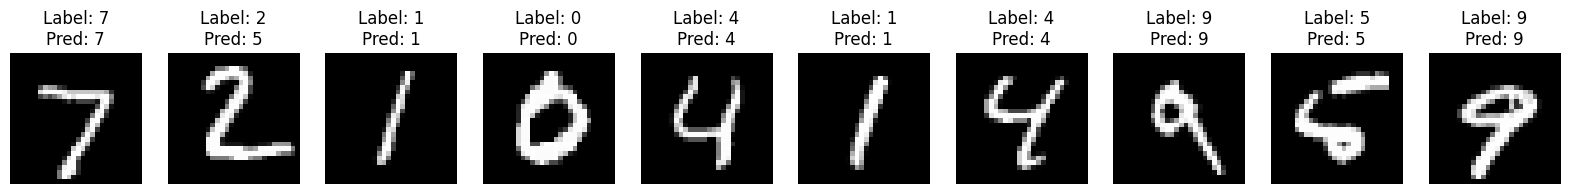

In [26]:
# Visualizar las imágenes con sus etiquetas y predicciones
fig, axes = plt.subplots(1, images_to_show, figsize=(20, 2))
for idx in range(images_to_show):
    image = images[idx].squeeze().numpy()
    label = labels[idx]
    prediction = predictions[idx]

    axes[idx].imshow(image, cmap='gray')
    axes[idx].set_title(f"Label: {label}\nPred: {prediction}")
    axes[idx].axis('off')

plt.show()

## Trabajo Individual
### Parte 1. Entrenando un modelo de clasificación con pesos preentrenados

En la primera parte de este laboratorio aprendimos a construir un modelo ViT desde cero y a entrenarlo utilizando el conjunto de datos MNIST.
Ahora, vamos a avanzar un paso más y aprenderemos a adaptar un modelo ViT preentrenado para el conjunto de datos CIFAR-100. Esta sección de trabajo invidivual esta dividida en dos parte. En esta primera parte aprenderemos a entrenar un modelo de clasificación con pesos preentrenados y en la segunda parte abordaremos modificaciones a modelos preentrenados. Este ejercicio te permitirá comprender cómo utilizar modelos preentrenados y ajustarlos para nuevas tareas, una habilidad muy valiosa en el campo de la visión por computadora.

**Objetivos del ejercicio:**
1. Cargar el conjunto de datos CIFAR-100.
2. Cargar un modelo ViT preentrenado.
3. Preparar los datos para el entrenamiento y evaluación del modelo.
4. Entrenar el modelo en el conjunto de entrenamiento de CIFAR-100.
5. Evaluar el rendimiento del modelo en el conjunto de prueba de CIFAR-100.

### 1.1 Cargar el conjunto de datos CIFAR-100

Lo primero que debemos hacer es cargar los datos de CIFAR-100. Para esto utilizamos una función de `datasets` denominada `load_dataset`. Esta función nos permite introducir como parámetro la base de datos que queremos descargar al igual que la cantidad de datos que deseamos tener en los diferentes conjuntos. En este caso utilizaremos 50000 datos para entrenar el modelo y 10000 datos para evaluarlo.

La función `datasets.load_dataset` retorna dos objetos de tipo `Dataset`. Uno para el conjunto de entrenamiento y otro para el conjunto de prueba. Una vez cargados los datos, imprime estos diccionarios para visualizar la estructura de ellos. Será importante entender esto para completar el ejercicio.

In [91]:
# Cargar los datasets descomprimidos
from datasets import load_from_disk

train_output_folder = './archivos_ViT/CIFAR100/train_dataset'
test_output_folder = './archivos_ViT/CIFAR100/test_dataset'
train_ds = load_from_disk(train_output_folder)
test_ds = load_from_disk(test_output_folder)

# Reducir el número de imágenes de entrenamiento y test
train_ds = train_ds.train_test_split(test_size=0.9, shuffle=True, seed=42)['train']
test_ds = test_ds.train_test_split(test_size=0.9, shuffle=True, seed=42)['train']

print(train_ds)
print(test_ds)

Dataset({
    features: ['img', 'fine_label', 'coarse_label'],
    num_rows: 5000
})
Dataset({
    features: ['img', 'fine_label', 'coarse_label'],
    num_rows: 1000
})


### 1.2 Cargar un modelo preentrenado

Ahora es momento de cargar el modelo preentrenado. Para esto vamos a utilizar las funciones `ViTConfig` y `ViTForImageClassification` para definir algunos parámetros del modelo y el modelo con pesos preentrenados respectivamente. La documentación de las funciones se encuentra en el siguiente link:
https://huggingface.co/transformers/v4.5.1/model_doc/vit.html

Te habras dado cuenta que la función `ViTConfig` requiere una serie de parámetros que serán luego utilizados para inicializar el modelo y ajustarlo a nuestros datos. Dentro estos parámetros se encuentra *num_labels*, *id2label* y *label2id*.

* *num_labels*: Este parámetro corresponde al número total de clases que el modelo debe clasificar y depende del número de clases presente en tu base de datos.
* *id2labels*: Este parámetro es un diccionario que asigna un índice a cada una de las clases presentes. En este caso las llaves del diccionario son números enteros del *0* al *num_labels - 1*, y los valores del diccionario son cadenas de texto que corresponden a los nombres de las clases. Una vez creado este diccionario, debería poder acceder a los nombres de las clases llamando su índice correspondiente. Por ejemplo, si el índice 0 corresponde a la clase "perro", entonces en el diccionario *id2label*, la llave 0 tendrá el valor "perro".
* *label2id*: Este parámetro es un diccionario que asigna un nombre de clase a su correspondiente índice. En este caso, las llaves del diccionario son cadenas de texto que corresponden a los nombres de las clases, y los valores del diccionario son números enteros del *0* al *num_labels - 1*. Una vez creado este diccionario, debería poder acceder a los índices de las clases llamando su nombre correspondiente. Por ejemplo, si la clase "perro" corresponde al índice 0, entonces en el diccionario *label2id*, la llave "perro" tendrá el valor 0.

**Pista:** Utiliza el objeto `Dataset` `train_ds`, definido anteriormente, para obtener la lista de los nombres de las clases. Al inspeccionar `train_ds` (`print(train_ds)`), notarás que este objeto tiene varias propiedades (*features*): `img`, `fine_label`, y `coarse_label`. La lista de los nombres de las clases se encuentra en la propiedad `fine_label`, que es un tipo de `ClassLabel`. Esta clase especial incluye propiedades adicionales, como el número de clases y una lista de los nombres de las clases. El siguiente enlace proporciona una explicación detallada sobre cómo acceder al contenido de un objeto `Dataset`. Enfócate en cómo acceder a los *features* dentro del objeto `Dataset`, y luego en cómo explorar la propiedad `fine_label` para obtener la lista de los nombres de las clases.

**What’s in the Dataset object:** https://huggingface.co/docs/datasets/v1.2.1/exploring.html

In [92]:
# Definir el nombre del modelo ViT preentrenado
#model_name = "google/vit-base-patch16-224"
# TODO: Calcula los parámetros necesarios para inicializar el modelo
## Completa desde aquí
model_name = "google/vit-base-patch16-224"
labels = train_ds.features['fine_label'].names
num_labels = train_ds.features['fine_label'].num_classes


id2label = {i: label for i, label in enumerate(labels)}
label2id = {label: i for i, label in enumerate(labels)}
## Completa hasta aquí

### A continuación revisa y guarda tu respuesta 1

In [93]:
assert type(num_labels) == int, 'Error en el cálculo de la cantidad de labels'
assert type(id2label) == dict, 'Error en la obtención del diccionario que mapea de ids a etiquetas'
assert type(label2id) == dict, 'Error en la obtención del diccionario que mapea de etiquetas a ids'
lm.verify_and_save(1, (num_labels, id2label, label2id), codigo_estudiante)

In [94]:
# Establecemos los parámetros del modelo
config = ViTConfig(
    hidden_size=768,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    finetuning_task="image-classification")


# Cargamos el modelo ViT preentrenado
model = ViTForImageClassification(config=config)
weights = torch.load('vit_weights.pt')
model.load_state_dict(weights)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTSdpaAttention(
            (attention): ViTSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_fe

### 1.3 Preparar los datos

Una vez cargados los datos y definido el modelo, es momento de preparar los datos para el entrenamiento. Primero, necesitamos procesar las imágenes para que tengan el formato correcto que espera el modelo. Para esto, utilizaremos la función `ViTImageProcessor` que normalizará y redimensionará las imágenes según los parámetros predefinidos del modelo. Luego, crearemos una función de collate para agrupar los datos en lotes (batches) de manera eficiente. Finalmente, usaremos `DataLoader` de PyTorch para crear iteradores que alimenten el modelo durante el entrenamiento y la evaluación.

In [95]:
# La función ViTImageProcessor.from_pretrained realiza este preprocesamiento, ajustando las imagenes al modelo preentrenado.
image_processor = ViTImageProcessor(True)

# Procesar todas las imagenes
def preprocess(example_batch):
    #example_batch["pixel_values"] = [transformations(image.convert("RGB")) for image in example_batch["img"]]
    example_batch["pixel_values"] = image_processor([img.convert("RGB") for img in example_batch["img"]], return_tensors="pt")["pixel_values"]
    return example_batch

train_dataset = train_ds.with_transform(preprocess)
test_dataset = test_ds.with_transform(preprocess)

# Crear el collator
def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["fine_label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

# Dataloaders
set_seed(42)
train_loader = DataLoader(train_dataset, shuffle=True, collate_fn=collate_fn, batch_size=64)
test_loader = DataLoader(test_dataset, collate_fn=collate_fn, batch_size=64)

### 1.4 Entrenar el modelo en el conjunto de entrenamiento

Para entrenar nuestro modelo preentrenado, debemos primero debemos definir la función de pérdida y el optimizador. Luego definimos parámetros como la tasa de aprendizaje y el número de épocas y finalmente estamos listos para ensamblar todo y entrenar nuestro modelo preentrenado en los datos de CIFAR-100. Define por favor la función de pérdida como Cross Entropy Loss y el optimizador como AdamW con una tasa de aprendizaje de 1e-05

In [96]:
# TODO: Define la función de pérdida como Cross Entropy Loss y el optimizador como AdamW con una tasa de aprendizaje de 0.00001

## Completa desde aquí
optimizer = optim.AdamW(model.parameters(), lr=1e-05)
criterion = nn.CrossEntropyLoss()
## Completa hasta aquí

# Definimos el número de épocas
num_epochs = 5

### A continuación revisa y guarda tu respuesta 2

In [97]:
assert type(optimizer) == optim.AdamW, 'Error al definir el optimizador'
assert type(criterion) == nn.CrossEntropyLoss, 'Error al definir la función de pérdida'
lm.verify_and_save(2, optimizer, codigo_estudiante)

Escribe el código para entrenar el modelo en el conjunto de entrenamiento por el número de épocas definidas anteriormente. Al final del entrenamiento el modelo se guarda en un archivo .pt. Por favor no cambies los nombres de las variables brindadas. Además, revisa el bucle de entrenamiento del ejemplo para tomarlo como base.

* **Ayuda:** El modelo recibe la imágen de entrada y la salida corresponde un objeto de tipo `ImageClassifierOutput` que contiene las predicciones junto con otros parámetros adicionales. Para acceder únicamente al tensor de predicciones aplica la siguiente transformación a la salida del modelo (output):
    *output = output.logits*

**Pista:** Revisa la función `def collate_fn` para entender cómo acceder a las imágenes y las etiquetas dentro del lote (batch), en el momento de recorrer el conjunto de datos de entrenamiento (*train_loader*). Ten en cuenta que la salida de la función `def collate_fn` corresponde a la estructura de un lote (bacth).
    

In [99]:
# -----------------  Autograder answer  ----------------- #
# TODO: Entrena el modelo de ViT en el conjunto de entrenamiento de CIFAR-100 por el número de épocas establecido anteriormente.
model.train()
set_seed(42)
for epoch in range(num_epochs):
    train_loss = 0.0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1} in training", leave=False):
        ## Completa desde aquí
        x, y = batch['pixel_values'].to(device), batch['labels'].to(device)
        output = model(x, labels=y)
        logits = output.logits
        loss = output.loss
        train_loss += loss.item()
        ## Completa hasta aquí
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    print(f"Epoch {epoch + 1}/{num_epochs} loss: {train_loss:.2f}")
print('Finished Training')

# Guardamos el modelo entrenado
torch.save(model.state_dict(), 'CIFAR100_vit_model.pth')

Epoch 1/5 loss: 311.32


Epoch 2/5 loss: 262.93


Epoch 3/5 loss: 213.32


Epoch 4/5 loss: 167.91


Epoch 5/5 loss: 128.80
Finished Training


### A continuación revisa y guarda tu respuesta 3

In [100]:
assert type(model) == ViTForImageClassification, 'Error en el entrenamiento del modelo'
try:
    model.load_state_dict(torch.load('CIFAR100_vit_model.pth'))
    lm.verify_and_save(3, model, codigo_estudiante)
except: 
    print('Error en el entrenamiento del modelo')


### 1.4 Evaluar el rendimiento del modelo en el conjunto de prueba de CIFAR-100

Después de entrenar nuestro modelo, es importante evaluar su rendimiento en un conjunto de datos de prueba para verificar su precisión y capacidad de generalización. Escribe el código para evaluar el modelo en el conjunto de prueba. Reporta la métrica de precisión *(acuraccy)* y el informe de clasificación, el cual brinda métricas detalladas por clase. Para esto, revisa el ejemplo brindado. Además, no cambies los nombres de las variables.

In [101]:
# TODO: Evalue el modelo de ViT en el conjunto de prueba de CIFAR-100 por el número de épocas establecido anteriormente.
model.load_state_dict(torch.load('CIFAR100_vit_model.pth'))
model.eval()

# Definimos las variables para registrar la pérdida y la métrica
test_loss = 0.0
correct = 0
total = 0
all_labels = []
all_predictions = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        ## Completa desde aquí
        x, y = batch['pixel_values'].to(device), batch['labels'].to(device)
        pred = model(x, labels=y)
        logits = pred.logits
        _, predicted = torch.max(logits, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()
        ### Completa hasta aquí     
        all_labels.extend(y.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())


Evaluating: 100%|██████████| 16/16 [00:06<00:00,  2.55it/s]


### A continuación revisa y guarda tu respuesta 4

In [102]:
assert len(all_labels) != 0, 'Errores en el loop de evaluación'
assert len(all_predictions) != 0, 'Errores en el loop de evaluación'
lm.verify_and_save(4, (total, correct, all_labels, all_predictions), codigo_estudiante)

In [103]:
# TODO: Reporta el accuracy

## Completa desde aquí
accuracy = (correct/total)*100
## Completa hasta aquí

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 77.50%


### A continuación revisa y guarda tu respuesta 5

In [104]:
assert type(accuracy) == float, 'Errores en el cálculo del accuracy'
lm.verify_and_save(5, accuracy, codigo_estudiante)

In [105]:
# TODO: Obten el informe de clasificación

target_names = [id2label[i] for i in range(100)]

## Completa desde aquí
report = classification_report(all_labels, all_predictions, target_names=target_names)
## Completa hasta aquí

print(report)

               precision    recall  f1-score   support

        apple       0.89      1.00      0.94         8
aquarium_fish       0.90      1.00      0.95         9
         baby       0.73      0.67      0.70        12
         bear       0.80      0.44      0.57         9
       beaver       0.50      0.83      0.62        12
          bed       0.92      1.00      0.96        11
          bee       0.71      0.71      0.71         7
       beetle       0.78      0.88      0.82         8
      bicycle       0.90      1.00      0.95         9
       bottle       1.00      0.90      0.95        10
         bowl       0.29      0.25      0.27         8
          boy       0.47      0.57      0.52        14
       bridge       0.80      0.67      0.73         6
          bus       0.67      0.75      0.71         8
    butterfly       0.88      0.88      0.88         8
        camel       0.75      1.00      0.86         3
          can       0.90      0.90      0.90        10
       ca

### A continuación revisa y guarda tu respuesta 6

In [106]:
assert type(report) == str, 'Errores en la obtención del reporte de clasificación'
lm.verify_and_save(6, report, codigo_estudiante)

### Parte 2. Modificación de modelos preentrenados

En la primera parte del trabajo individual, aprendimos a adaptar un modelo ViT preentrenado para el conjunto de datos CIFAR-100. Ahora, vamos a explorar cómo podemos modificar y ajustar la arquitectura de un modelo preentrenado para experimentar con su rendimiento. Utilizaremos modelos preentrenados como base y añadiremos nuevas capas y técnicas de regularización, tales como Dropout, capas lineales adicionales, capas de normalización y activaciones no lineales.

**Objetivos del Ejercicio:**

1. Implementar una clase ModifiedCustomViT que integre Dropout, Layer Normalization, Batch Normalization, capas lineales adicionales y activaciones no lineales.
2. Entrenar el modelo avanzado en el conjunto de datos CIFAR-100.
3. Evaluar el rendimiento del modelo avanzado en el conjunto de prueba de CIFAR-100 y analizar el impacto de las modificaciones.

### 2.1 Implementar clase *ModifiedCustomViT*

Primero, define la clase `ModifiedCustomViT` que herede de nn.Module. El primer componente de nuestro ViT mejorado será el ViT preentrenado base. Utilizaremos la función `ViTModel` para extraer características de alto nivel de las imágenes de entrada. La función `from_pretrained` carga los pesos preentrenados del modelo. Usamos `ViTModel` en lugar de `ViTForImageClassification` porque `ViTModel` nos permite acceder directamente a las capas del transformador sin incluir la cabeza de clasificación predefinida. Esto nos da la flexibilidad de agregar nuestras propias capas y aplicar técnicas avanzadas de ajuste antes de la capa final de clasificación.

In [107]:
class ModifiedCustomViT(nn.Module):
    def __init__(self, model_name, config):
        super(ModifiedCustomViT, self).__init__()
        # ViT base preentrenado
        self.vit = ViTModel(config=config)
        self.vit.load_state_dict(weights)

    def forward(self, pixel_values):
        # Obtener las salidas del ViTModel
        x = self.vit(pixel_values)
        x = x.last_hidden_state[:, 0]  # Usamos la salida del token [CLS]
        return x

Ahora que tenemos nuestro ViT preentrenado, es momento de agregar los componentes que adicionales a nuestro. Los componente que agregaremos cumplen las siguientes funciones:

1. **Capa de Normalización:** Normaliza las salidas de ViTModel para mejorar la estabilidad y acelerar el entrenamiento. Ayuda a mantener la escala de las activaciones dentro de un rango razonable.

2. **Capas Lineales Adicionales:** Añaden capacidad adicional al modelo, permitiendo que el modelo aprenda representaciones más complejas. Estas capas se aplican después de la normalización y están seguidas de activaciones no lineales y dropout.

3. **Activaciones No Lineales:** Introducen no linealidades que ayudan al modelo a capturar patrones más complejos en los datos.

4. **Dropout:** Ayuda a prevenir el sobreajuste al desactivar aleatoriamente algunas neuronas durante el entrenamiento. Esto obliga al modelo a aprender características redundantes, haciendo que generalice mejor.

5. **Conexiones Residuales:** Facilitan el flujo de gradientes a través de la red, lo que mejora el entrenamiento de redes profundas al conectar la entrada de una capa a su salida.

6. **Cabeza de Clasificación:** Transforma las características aprendidas por el modelo en predicciones para las clases específicas de CIFAR-100.

**El orden** en que agregamos estos componentes es fundamental y tiene un alto impacto en el rendimiento del modelo. Agrega los componentes descritos anteriormente al modelo:

1. Capa de normalización (utiliza *hidden_size* como la dimensión de la entrada)
2. Primera capa lineal (utiliza *hidden_size* como la dimensión de la entrada y de la salida)
3. Activación no lineal (GELU)
4. Dropout de 0.3
5. Segunda capa lineal (utiliza *hidden_size* como la dimensión de la entrada y de la salida)
6. Activación no lineal (GELU)
7. Dropout de 0.3
8. Cabeza (capa) de clasificación (utiliza *hidden_size* como la dimensión de la entrada y el número de clases como la dimensión de salida)

Además de estos componentes, vamos a agregar una conexión residual entre la salida de la normalización y la salida de la segunda capa después de la activación no lineal y el dropout. Completa la sección del código que falta, agregando los componentes ya descritos a la arquitectura. Por favor no cambies los nombres de las variables. 

In [108]:
class ModifiedCustomViT(nn.Module):
    def __init__(self, model_name, config):
        super(ModifiedCustomViT, self).__init__()
        self.vit = ViTModel(config=config)
        self.vit.load_state_dict(weights, strict=False)
        # Dimensiones ocultas
        self.hidden_size = config.hidden_size
        # Número de clases
        self.num_labels = config.num_labels
        # TODO: Agregar capas adicionales y cabeza de clasificación final (NO CAMBIAR LOS NOMBRES DE LAS CAPAS ESTABLECIDOS)

        ## Completa desde aquí
        
        # Capa de normalización
        self.additional_norm = nn.LayerNorm(self.hidden_size)
        # Capa lineal 1
        self.additional_linear1 = nn.Linear(self.hidden_size, self.hidden_size)
        # No activacion
        self.activation1 = nn.GELU()
        # Dropout
        self.dropout1 = nn.Dropout(0.3)
        # Capa lineal 2
        self.additional_linear2 = nn.Linear(self.hidden_size, self.hidden_size)
        # No activacion
        self.activation2 = nn.GELU()
        # Dropout
        self.dropout2 = nn.Dropout(0.3)
        # Cabeza de clasificación final
        self.classifier = nn.Linear(self.hidden_size, self.num_labels)
        
        ## Completa hasta aquí

    def forward(self, pixel_values):
        x = self.vit(pixel_values)
        x = x.last_hidden_state[:, 0]  # Usamos la salida del token [CLS]
        #Modificaciones del modelo
        #Normalización
        normalized_output = self.additional_norm(x)
        # Capa lineal adicional
        linear_output1 = self.additional_linear1(normalized_output)
        # Activacion no lineal
        activated_output1 = self.activation1(linear_output1)
        # Dropout
        dropped_output1 = self.dropout1(activated_output1)
        # Capa lineal adicional
        linear_output2 = self.additional_linear2(dropped_output1)
        # Activacion no lineal
        activated_output2 = self.activation2(linear_output2)
        # Dropout
        dropped_output2 = self.dropout2(activated_output2)
        # Conexión residual
        final_output = dropped_output2 + normalized_output
        # Cabeza de clasificación
        x = self.classifier(final_output)

        return x
set_seed(42)
mod_model = ModifiedCustomViT(model_name, config)
mod_model.to(device)
mod_model.load_state_dict(torch.load('mod_model_weights_0.pth'))

<All keys matched successfully>

### A continuación revisa y guarda tu respuesta 7

In [109]:
assert type(mod_model.additional_norm) == nn.LayerNorm, 'Errores en la definición de la normalización'
assert type(mod_model.additional_linear1) == nn.Linear and type(mod_model.additional_linear2) == nn.Linear, 'Errores en la definición de las capas lineales'
assert type(mod_model.activation1) == nn.GELU and type(mod_model.activation2) == nn.GELU, 'Errores en la definición de las funciones de activación'
assert type(mod_model.dropout1) == nn.Dropout and type(mod_model.dropout2) == nn.Dropout, 'Errores en la definición de las capas de dropout'
assert type(mod_model.classifier) == nn.Linear, 'Errores en la definición de la cabeza de clasificación'
lm.verify_and_save(7, mod_model, codigo_estudiante)

### 2.2 Entrenar el modelo avanzado en el conjunto de datos CIFAR-100

Para entrenar el modelo avanzado debemos nuevamente definir la función de pérdida, el optimizador y los parámetro de entrenamiento como la tasa de aprendizaje y el número de época. Luego, inicializamos el modelo y lo entrenamos en todo el conjunto de entrenamiento por el número de épocas definido anteriormente. Por favor define la función de pérdida como Cross Entropy Loss y el optimizador como Adam con una tasa de aprendizaje de 5e-05

In [110]:
# TODO: Define la función de pérdida como el Cross Entropy Loss optimizador usando Adam y una tasa de aprendizaje de 0.00005

## Completa desde aquí
optimizer = optim.Adam(mod_model.parameters(), lr=5e-05)
criterion = nn.CrossEntropyLoss()
## Completa hasta aquí

# Definimos el número de épocas
num_epochs = 10

### A continuación revisa y guarda tu respuesta 8

In [111]:
assert type(optimizer) == optim.Adam, 'Error al definir el optimizador'
assert type(criterion) == nn.CrossEntropyLoss, 'Error al definir la función de pérdida'
lm.verify_and_save(8, optimizer, codigo_estudiante)

Escribe el código para entrenar el modelo en el conjunto de entrenamiento por el número de épocas definidas anteriormente. Al final del entrenamiento el modelo se guarda en un archivo .pt. Recuerda basarte en el ciclo de entrenamiento brindado en el ejemplo.

* **Ayuda:** El modelo recibe la imágen de entrada y la salida depende de lo que retorne tu función `ModifiedCustomViT`. El *return* del *forward* determina cómo acceder correctamente a las predicciones. Dado que el *return* corresponde únicamente a x, se puede concluir que la salida del modelo (*output = mod_model(input)*) corresponde directamente a la predicción (es decir *output* = *prediction*) y no hay necesidad de realizar ningún ajuste.

**Pista:** Revisa la función `def collate_fn` para entender cómo acceder a las imágenes y las etiquetas dentro del lote (batch), en el momento de recorrer el conjunto de datos de entrenamiento (*train_loader*). Ten en cuenta que la salida de la función `def collate_fn` corresponde a la estructura de un lote (bacth).

In [112]:
# TODO: Entrena el modelo de ViT en el conjunto de entrenamiento de CIFAR-100 por el número de épocas definido anteriormente
mod_model.train()
set_seed(42)

for epoch in range(num_epochs):
    train_loss = 0.0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1} in training", leave=False):
        ### Completa desde aquí
        x, y = batch['pixel_values'].to(device), batch['labels'].to(device)
        pred = mod_model(x)
        loss = criterion(pred, y)
        train_loss += loss.item()
        ### Completa hasta aquí
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    print(f"Epoch {epoch + 1}/{num_epochs} loss: {train_loss:.2f}")
print('Finished Training')

# Guardamos el modelo entrenado
torch.save(mod_model.state_dict(), 'CIFAR100_modified_vit_model.pth')

Epoch 1/10 loss: 349.61


Epoch 2/10 loss: 328.05


Epoch 3/10 loss: 310.86


Epoch 4/10 loss: 297.05


Epoch 5/10 loss: 284.01


Epoch 6/10 loss: 270.49


Epoch 7/10 loss: 256.08


Epoch 8/10 loss: 244.24


Epoch 9/10 loss: 231.39


Epoch 10/10 loss: 216.30
Finished Training


### A continuación revisa y guarda tu respuesta 9

In [113]:
assert type(mod_model) == ModifiedCustomViT, 'Error en el entrenamiento del modelo'
try:
    mod_model.load_state_dict(torch.load('CIFAR100_modified_vit_model.pth'))
    lm.verify_and_save(9, mod_model, codigo_estudiante)
except: print('Error en el entrenamiento del modelo')

### 2.3 Evaluar el rendimiento del modelo avanzado en el conjunto de prueba de CIFAR-100

Finalmente, debemos evaluar el rendiminto del modelo en el conjunto de datos de prueba. Escribe el código para evaluar el modelo en el conjunto de prueba. Reporta la métrica de precisión *(acuraccy)* y el informe de clasificación, el cual brinda métricas detalladas por clase. Recuerda que tu código debe estar inspirado en el ejemplo y que no debes cambiar los nombres de las variables. Además, una vez evaluado el modelo, compara los resultados con el modelo anterior para determinar si las modificaciones realizadas tuvieron un impacto positivo en la capacidad de clasificación del modelo. F

In [114]:
# TODO: Evalue el modelo de ViT en el conjunto de prueba de CIFAR-100
mod_model.load_state_dict(torch.load('CIFAR100_modified_vit_model.pth'))
mod_model.eval()

test_loss = 0.0
correct = 0
total = 0
all_labels = []
all_predictions = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        ## Completa desde aquí
        x, y = batch['pixel_values'].to(device), batch['labels'].to(device)
        pred = mod_model(x)
        _, predicted = torch.max(pred, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()
        ## Completa hasta aquí

        all_labels.extend(y.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())





Evaluating: 100%|██████████| 16/16 [00:06<00:00,  2.40it/s]


### A continuación revisa y guarda tu respuesta 10

In [115]:
assert len(all_labels) != 0, 'Errores en el loop de evaluación'
assert len(all_predictions) != 0, 'Errores en el loop de evaluación'
lm.verify_and_save(10, (total, correct, all_labels, all_predictions), codigo_estudiante)

In [116]:
# TODO: Reporta las métricas de accuracy y el reporte de clasificación

## Completa desde aquí
accuracy = (correct/total)*100
## Completa hasta aquí

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 16.10%


### A continuación revisa y guarda tu respuesta 11

In [117]:
assert type(accuracy) == float, 'Errores en el cálculo del accuracy'
lm.verify_and_save(11, accuracy, codigo_estudiante)

In [118]:
target_names = [id2label[i] for i in range(100)]

## Completa desde aquí
report = classification_report(all_labels, all_predictions, target_names=target_names)
## Completa hasta aquí

print(report)

               precision    recall  f1-score   support

        apple       0.24      0.50      0.32         8
aquarium_fish       0.00      0.00      0.00         9
         baby       0.15      0.17      0.16        12
         bear       0.00      0.00      0.00         9
       beaver       0.00      0.00      0.00        12
          bed       0.00      0.00      0.00        11
          bee       0.00      0.00      0.00         7
       beetle       0.05      0.12      0.07         8
      bicycle       0.20      0.11      0.14         9
       bottle       0.12      0.10      0.11        10
         bowl       0.00      0.00      0.00         8
          boy       0.16      0.36      0.22        14
       bridge       0.25      0.50      0.33         6
          bus       0.33      0.25      0.29         8
    butterfly       0.50      0.12      0.20         8
        camel       0.29      0.67      0.40         3
          can       0.27      0.30      0.29        10
       ca

### A continuación revisa y guarda tu respuesta 12

In [119]:
assert type(report) == str, 'Errores en la obtención del reporte de clasificación'
lm.verify_and_save(12, report, codigo_estudiante)

### A continuación guarda todas las respuestas en un archivo para obtener tu calificación via email

In [120]:
lm.save_answers(codigo_estudiante)